# XGBFR 06 — Selected Threshold Validation

Review the selected threshold by fold, FSA, horizon, and M9W-2023 before approving the freeze.

In [3]:
# Import libraries
from pathlib import Path
import sys
import matplotlib.pyplot as plt


In [ ]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "peak_risk_final_refinement.yaml"
)

CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/peak_risk_final_refinement.yaml')

In [4]:
# Import module for Final Refinement Analysis
from src.ontario_peak_risk.models.peak_risk.final_refinement.run_refinement import (
    run_final_refinement,
)
from src.ontario_peak_risk.models.peak_risk.final_refinement.plotting import (
    precision_recall_f1_by_fold,
    false_negative_tradeoff,
    stability_plot,
    m9w_tradeoff_plot,
    selected_metric_by_horizon,
)


XGBOOST PEAK-RISK FINAL REFINEMENT COMPLETED
Selected operational threshold: 0.06
Algorithm / features / hyperparameters: unchanged
Freeze manifest: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\outputs\modeling\peak_risk\xgboost_final_refinement\XGBC_FINAL_FREEZE_MANIFEST.json
2025 final holdout evaluated: NO


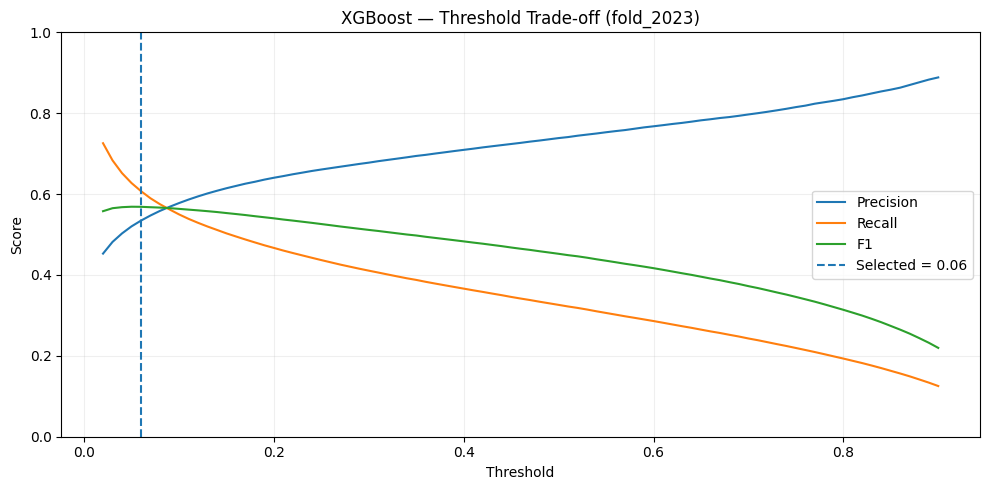

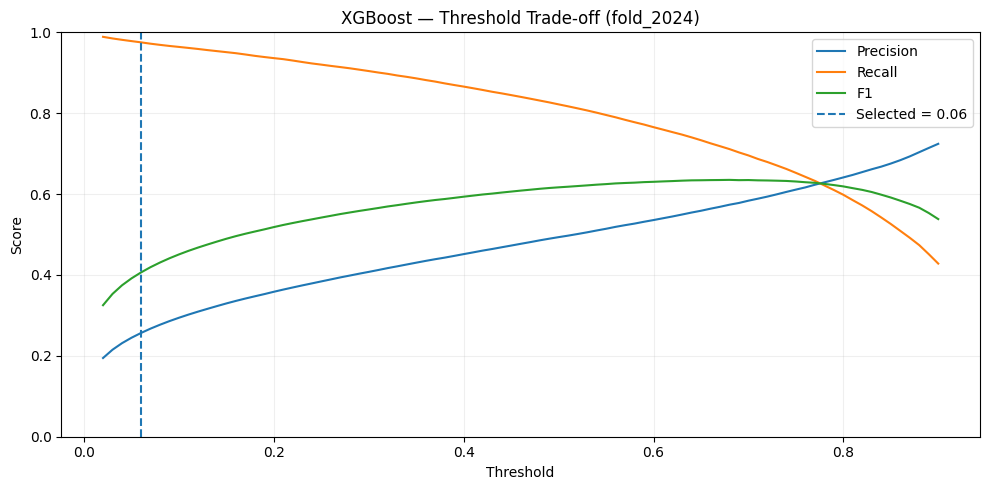

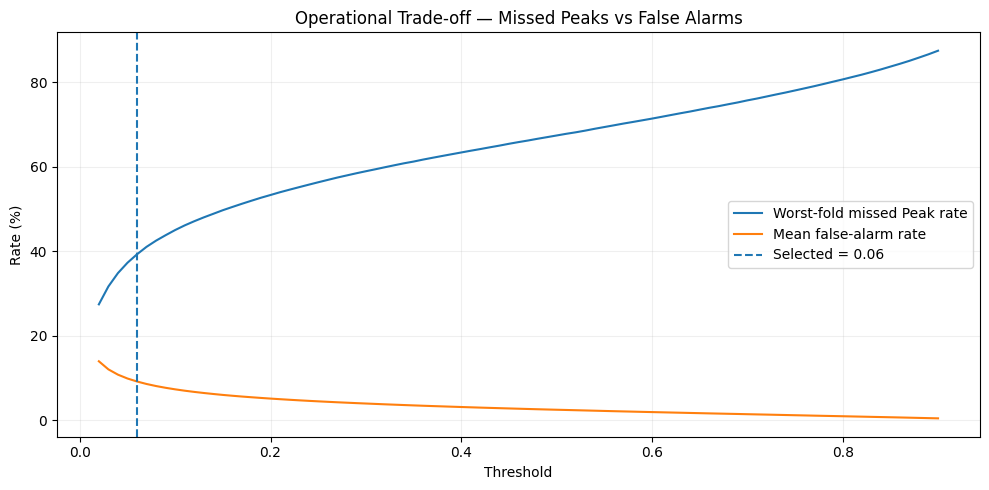

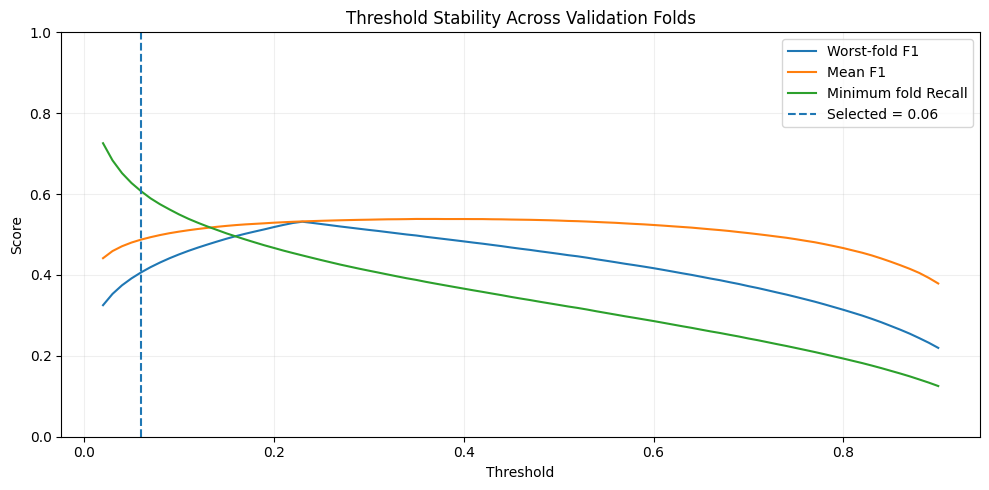

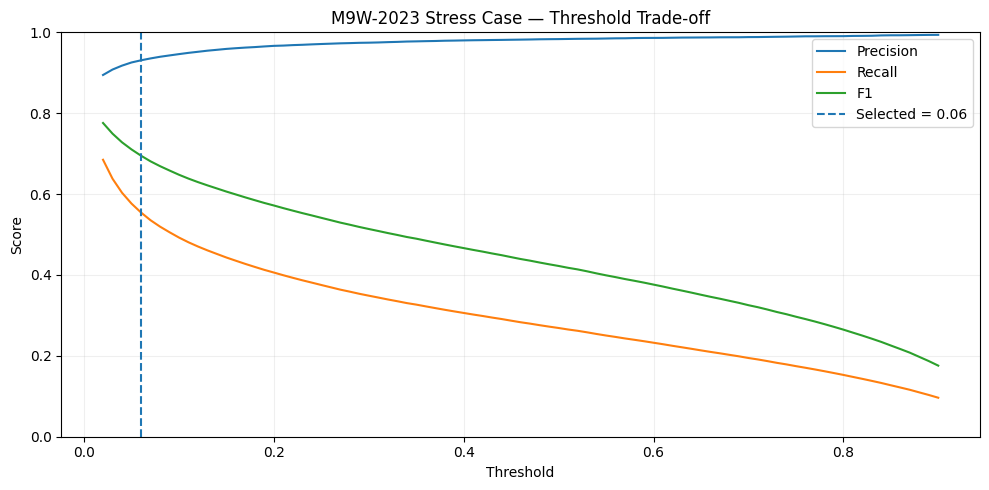

,threshold,precision,recall,f1,balanced_accuracy,true_positive,false_positive,false_negative,true_negative,missed_peak_rate_pct,false_alarm_rate_pct,predicted_peak_rate_pct,actual_peak_rate_pct,n_observations
4,0.06,0.930824,0.554465,0.694961,0.755439,59758,4441,48018,97447,44.553518,4.358708,30.619944,51.404151,209664


In [ ]:
# Run final Refinement
results = run_final_refinement(CONFIG_PATH)
threshold = results["selected_threshold"]

for fig in precision_recall_f1_by_fold(results["fold_sweep"], threshold):
    plt.show()

false_negative_tradeoff(results["fold_summary"], threshold)
plt.show()

stability_plot(results["fold_summary"], threshold)
plt.show()

if not results["m9w_stress"].empty:
    m9w_tradeoff_plot(results["m9w_stress"], threshold)
    plt.show()

display(results["m9w_selected"])


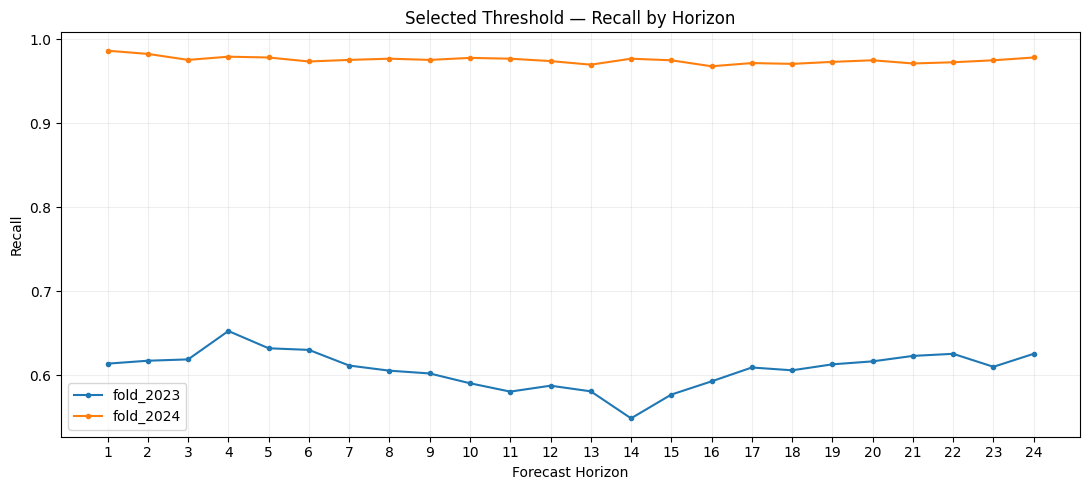

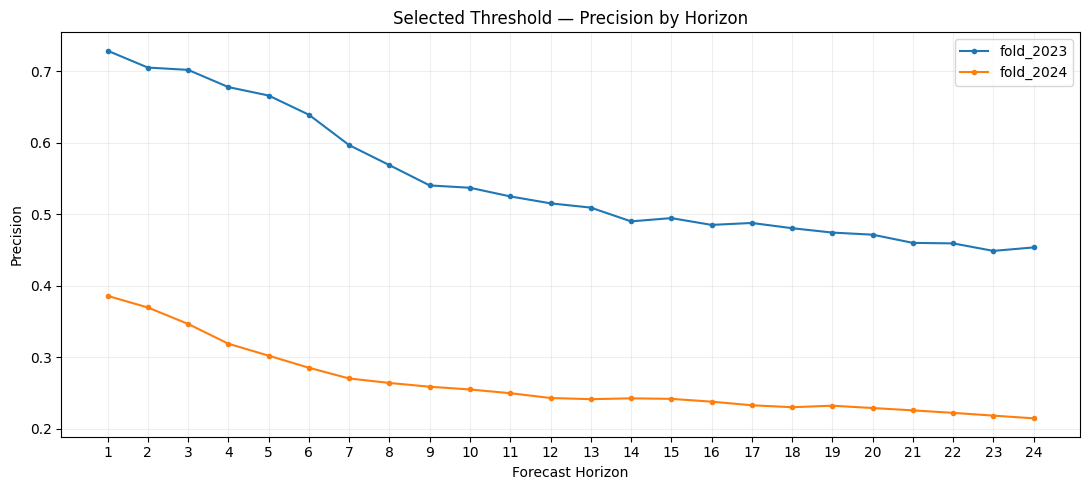

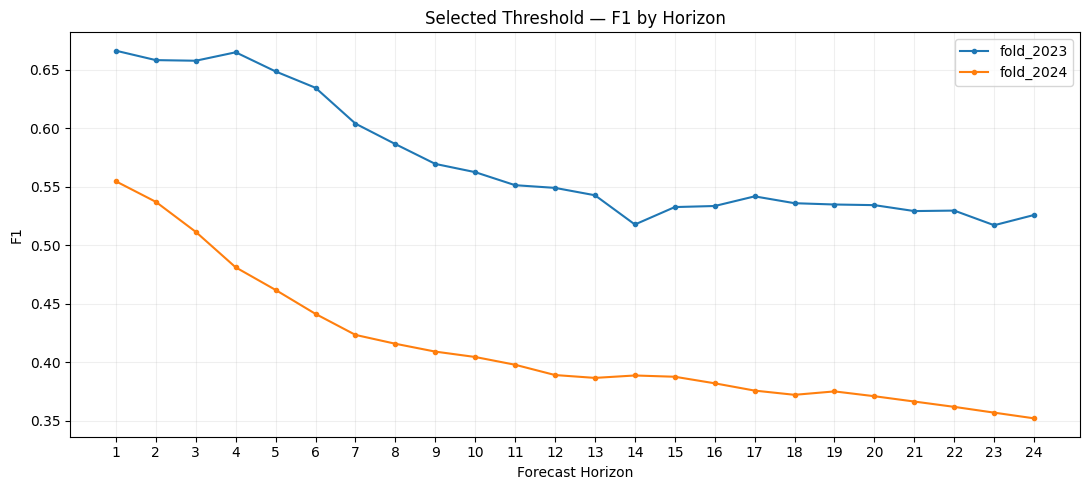

In [6]:
# 
selected_horizon = results["selected_evaluation"]["horizon"]

selected_metric_by_horizon(selected_horizon, "recall")
plt.show()

selected_metric_by_horizon(selected_horizon, "precision")
plt.show()

selected_metric_by_horizon(selected_horizon, "f1")
plt.show()


In [7]:
display(
    results["selected_evaluation"]["fsa"]
    .sort_values(["fold", "recall"])
)


,fold,fsa,threshold,precision,recall,f1,balanced_accuracy,true_positive,false_positive,false_negative,true_negative,missed_peak_rate_pct,false_alarm_rate_pct,predicted_peak_rate_pct,actual_peak_rate_pct,n_observations
5,fold_2023,M9W,0.06,0.930824,0.554465,0.694961,0.755439,59758,4441,48018,97447,44.553518,4.358708,30.619944,51.404151,209664
0,fold_2023,L4T,0.06,0.156775,0.752510,0.259488,0.837056,2998,16125,986,189555,24.748996,7.839848,9.120784,1.900183,209664
3,fold_2023,M6G,0.06,0.396634,0.762149,0.521744,0.846851,8908,13551,2780,184425,23.785079,6.844769,10.711901,5.574634,209664
4,fold_2023,M9R,0.06,0.250598,0.802779,0.381961,0.859605,5662,16932,1391,185679,19.722104,8.356901,10.776290,3.363954,209664
1,fold_2023,M5R,0.06,0.245130,0.847384,0.380259,0.897487,3498,10772,630,194764,15.261628,5.240931,6.806128,1.968864,209664
2,fold_2023,M5S,0.06,0.208868,0.888889,0.338255,0.917425,2944,11151,368,195201,11.111111,5.403873,6.722661,1.579670,209664
8,fold_2024,M5S,0.06,0.189979,0.962535,0.317327,0.953008,2749,11721,107,195663,3.746499,5.651834,6.882610,1.358447,210240
11,fold_2024,M9W,0.06,0.358895,0.970167,0.523961,0.882659,21561,38515,663,149501,2.983261,20.484959,28.574962,10.570776,210240
9,fold_2024,M6G,0.06,0.220142,0.973877,0.359109,0.921748,7456,26413,200,176171,2.612330,13.038048,16.109684,3.641553,210240
10,fold_2024,M9R,0.06,0.250775,0.979127,0.399284,0.928451,8256,24666,176,177142,2.087287,12.222509,15.659247,4.010654,210240
